# TODO: ADD LEARNING RATE SCHEDULER???
# USE TEST DATASET TO CONFIRM VALIDATION???
# ADD A FADE IN

# Car Segmentation Task with Nested U-Net Architecture

## Download dataset from Kaggle
Make sure to:
- Join competition on Kaggle
- Register API
- Export data from the zip folders

In [1]:
import kaggle
import os

kaggle.api.authenticate()

files = ["train.zip", "train_masks.zip"]

if len(os.listdir("../Car-Segmentation-UNET/.kaggle")) < len(files):
    # Download each file
    for file in files:
        kaggle.api.competition_download_file(competition="carvana-image-masking-challenge", file_name=file, path=".kaggle")

### Files that can be extracted

In [2]:
!kaggle competitions files -c carvana-image-masking-challenge

name                        size  creationDate         
-------------------------  -----  -------------------  
train.zip                  405MB  2018-06-22 02:52:10  
test.zip                     8GB  2018-06-22 02:52:10  
test_hq.zip                 15GB  2018-06-22 02:52:10  
train_hq.zip               804MB  2018-06-22 02:52:10  
metadata.csv.zip            81KB  2018-06-22 02:52:10  
train_masks.csv.zip         15MB  2018-06-22 02:52:10  
29bb3ece3180_11.jpg        107KB  2018-06-22 02:52:10  
sample_submission.csv.zip  202KB  2018-06-22 02:52:10  
train_masks.zip             29MB  2018-06-22 02:52:10  


## Import modules

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import torch.nn.functional as F

from torchvision import transforms
from torchvision.utils import save_image
import torchvision.transforms.functional as VT

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import imageio

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Define device used for training
device, pin_memory = torch.device('cuda' if torch.cuda.is_available() else 'cpu'), torch.cuda.is_available()

# Root directory for dataset
dataroot = "../Car-Segmentation-UNET/.kaggle"

# Specify image dimensions
img_height = 320
img_width = 480

# Directories
image_dir = '../Car-Segmentation-UNET/.kaggle/train'
mask_dir = '../Car-Segmentation-UNET/.kaggle/train_masks'
model_output_folder = "model_outputs"

# Epochs to train for (if not stopped early)
num_epochs = 200

# Batch size for dataloading
batch_size = 4

# Pretrained model settings
use_pretrained = False
continue_training = True
checkpoint_path = "models\\model.pth"

# Enable deep-supervision (Used in paper)
deep_supervision = True

# Percentage of data in the train set
train_split = 0.9

# Model parameters
IN_CHANNELS = 3
OUT_CHANNELS = 1
L = 4

# List to keep track of iou over each epoch of training
iou_score_track = []
dice_score_track = []
val_loss_track = []

images = []

if use_pretrained:
    checkpoint = torch.load(checkpoint_path)
    deep_supervision = checkpoint['deep_supervision']
    iou_score_track = checkpoint['iou_track']
    dice_score_track = checkpoint['dice_track']
    val_loss_track = checkpoint['val_track']
    IN_CHANNELS = checkpoint['in_channels']
    OUT_CHANNELS = checkpoint['out_channels']
    L = checkpoint['L']
    images = checkpoint['images']
    test_image = checkpoint['test_image']
    test_mask = checkpoint['test_mask']

## Data Preparation

### Create Custom Dataset
This class handles transforming the requested image to fit the model

In [4]:
class ImageDataset(Dataset):
    def __init__(self, image_dir, split_index, mask_dir, mode='train', transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        if mode == 'train':
            self.image_files = sorted(os.listdir(image_dir))[:split_index]
            self.mask_files = sorted(os.listdir(mask_dir))[:split_index]
        elif mode == 'test':
            self.image_files = sorted(os.listdir(image_dir))[split_index:]
            self.mask_files = sorted(os.listdir(mask_dir))[split_index:]
        self.transform = transform
        self.mode = mode

    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, index):
        img_path = os.path.join(self.image_dir, self.image_files[index])
        mask_path = os.path.join(self.mask_dir, self.mask_files[index])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")
        
        if self.transform:
            flip = False
            if self.mode == 'train' and np.random.random() > 0.5:
                flip = True
            image = self.transform(image)
            mask = self.transform(mask)
            mask = mask * (mask == 1.0)
            if flip:
                image = torch.flip(image, dims=[2])
                mask  = torch.flip(mask , dims=[2])

        return image, mask

### Define transform for data, datasets, and dataloaders

In [5]:
transform = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.ToTensor(),
])

train_size = int(len(os.listdir(image_dir)) * train_split)
test_size = len(os.listdir(image_dir)) - train_size

train_dataset = ImageDataset(image_dir=image_dir, mask_dir=mask_dir, split_index=train_size, transform=transform)
test_dataset = ImageDataset(image_dir=image_dir, mask_dir=mask_dir, split_index=train_size, mode='test', transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=pin_memory)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=pin_memory)

### Test image transform to consist of only black ($0.0$) or white ($1.0$) pixels.

In [6]:
value_counts = {}

for x in train_dataset[0][1].flatten():
    if x.item() in value_counts:
        value_counts[x.item()] += 1
    else:
        value_counts[x.item()] = 1

assert len(value_counts) == 2, "Values of masks must equal 0.0 or 1.0"
value_counts

{0.0: 127071, 1.0: 26529}

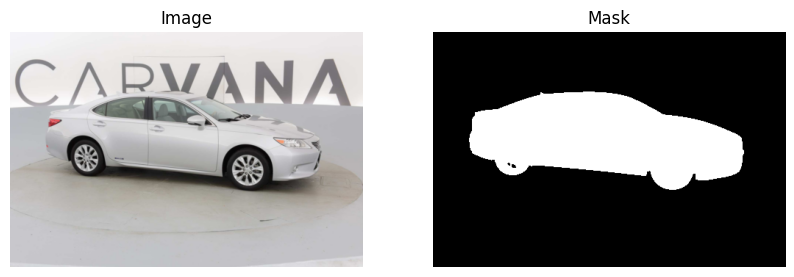

In [11]:
if not use_pretrained:
    # Select a random sample
    idx = np.random.randint(0, len(test_dataset))
    test_image, test_mask = test_dataset[idx]

# Convert tensors to NumPy format for plotting
image = test_image.permute(1, 2, 0).numpy()
mask = test_mask.permute(1, 2, 0).numpy()

# Plot side by side
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(image)
ax[0].set_title("Image")
ax[0].axis("off")

ax[1].imshow(mask, cmap='gray') # Use grayscale colormap for mask
ax[1].set_title("Mask")
ax[1].axis("off")

plt.show()

## Create Nested U-Net Model
The Nested U-Net architecture is a sophisticated implementation of the vanilla U-Net architecture. The U-Net++ consists of an encoder (refered to as the "backbone") and decoder that are connected through many nested dense convolutional blocks. What distinguishes the UNet++ from the vanilla U-Net is the re-designed skip pathways.

![alt text](UNET++_Architecture.png "UNET")

### Implementation in PyTorch

#### 

#### Denoted in the paper as: $X^{i,j} \text{ Convolution}$

In [12]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ConvBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=out_channels, out_channels=out_channels, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

#### Re-designed skip pathways
![alt text](SkipConnectionEquations.png "U-NET++")

#### Create U-NET++

In [13]:
class UNET(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, first_feature=32, L=4, deep_supervision=True, device='cpu'):
        super(UNET, self).__init__()

        # Ensure the proper parameters are given
        assert isinstance(in_channels, int), "in_channels must be an integer"
        assert isinstance(out_channels, int), "out_channels must be an integer"
        assert isinstance(first_feature, int), "first_feature must be an integer"
        assert isinstance(L, int), "L must be an integer"
        assert L <= 4 and L > 0, "L must be in range [1, 5)"
        assert isinstance(deep_supervision, bool), "deep_supervision must be True or False"

        # L is used in defining how deep the network is. Essentially, there will be L + 1 layers (top to bottom of triangular architecture)
        # with each layer having one less cell than the last. Paper uses L in range [1, 4]
        self.L = L

        # Device to send tensors to
        self.device = device

        # Deep supervision will define if the model backward propogates using all cells of the top layer (excluding backbone)
        self.deep_supervision = deep_supervision

        # Feature dimensionality of the model (paper starts with 32 and increases by 2 each layer)
        features = [first_feature * 2 ** x for x in range(0, L + 1, 1)]

        # Backbone modules and pooling
        self.backbone = nn.ModuleList([])
        self.pool = nn.MaxPool2d(2, 2)

        # Create dense convolutional blocks as backbone
        for feature in features:
            self.backbone.append(ConvBlock(in_channels, feature))
            in_channels = feature

        # Create 2-dimensional list of nested dense convolutional blocks
        self.layers = nn.ModuleList([
            nn.ModuleList([ConvBlock(features[i] * 1 + features[i+1], features[i]) for i in range(L)]),
            nn.ModuleList([ConvBlock(features[i] * 2 + features[i+1], features[i]) for i in range(L - 1)]),
            nn.ModuleList([ConvBlock(features[i] * 3 + features[i+1], features[i]) for i in range(L - 2)]),
            nn.ModuleList([ConvBlock(features[i] * 4 + features[i+1], features[i]) for i in range(L - 3)]),
        ])[:L] # Only use the first L layers

        # Upsampling used in paper
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        # Output module depending on deepsupervision
        if deep_supervision:
            self.deep_layers = nn.ModuleList([
                nn.Conv2d(features[0], out_channels, kernel_size=1) for _ in range(L)
            ])
        else:
            self.output = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        # Skip connections array, updates to skip_connections will eventually form 
        # what looks like an upper triangular matrix the is flipped horizontally
        skip_connections = []

        # Create the backbone
        back_bone_skip = []
        for idx, block in enumerate(self.backbone): #  Iterate backbone layers
            x = block(x)             #  Forward propagation for each layer of backbone
            back_bone_skip.append(x) #  Append skip connection to backbone
            if idx != self.L:        #  Not necessary to pool for last layer of backbone
                x = self.pool(x)     #  Max pool for next layer

        # Append backbone layer to skip connections and delete back_bone skip from memory
        # because it won't be used anymore
        skip_connections.append(back_bone_skip)
        del back_bone_skip

        # Iterate throught all nested layers
        for i in range(len(self.layers)):
            layer_skips = []                                        #  Array that holds the output skips for each cell in layer
            for l, layer in enumerate(self.layers[i]):              #  Enumerate the nested cells in layer
                cat_connections = []                                #  Connections to concatenate after forward propagation
                for k in range(i + 1):                              #  Iterate all previous cells in layer besides backbone
                    cat_connections.append(skip_connections[k][l])  #  Append nested cell to concatenate later
                cat_connections.append(self.up(skip_connections[i][l+1]))
                cat_connection = torch.cat(cat_connections, dim=1)  #  Finally, concatenate all cells to propagate through the next
                layer_skip = layer(cat_connection)                  #  Forward propagation for next cell
                layer_skips.append(layer_skip)                      #  Append new cell forward propagation to layer skips

            skip_connections.append(layer_skips)                    # Add layer skips to skip connections

        # We only want the output of each cell in the top row of architecture (besides backbone)
        # If not using deep supervision, use the output of cell x_(0, L)
        if self.deep_supervision: 
            return [self.deep_layers[x](skip_connections[x+1][0]) for x in range(self.L)]
        else: 
            return self.output(skip_connections[-1][-1])
        
    def train_step(self, loader: DataLoader, criterion, optimizer: torch.optim.Adam, epoch: int, num_epochs: int, miniters: int=10):
        self.train()
        total_loss = 0
        loop = tqdm(loader, total=len(loader), desc=f"[{epoch+1}/{num_epochs}] loss=inf", miniters=miniters)
        for idx, (x_batch, y_batch) in enumerate(loop):
            x_batch: torch.Tensor
            y_batch: torch.Tensor
            x_batch, y_batch = x_batch.to(self.device), y_batch.to(self.device)

            optimizer.zero_grad()

            if self.deep_supervision:
                logits = self(x_batch)
                loss = 0
                for logit in logits:
                    loss += criterion(logit, y_batch)
                loss /= len(logits)
            else:
                logits = self(x_batch)
                logits = logits.squeeze(1)
                loss = criterion(logits, y_batch.squeeze(1))
            
            total_loss += loss.item()
            
            if (idx + 1) % miniters == 0:
                loop.desc = f"[{epoch+1}/{num_epochs}] loss={(total_loss / (idx + 1)):.4f}"

            loss.backward()
            optimizer.step()

        return total_loss / len(loader)
    
    @torch.no_grad()
    def evaluate(self, loader: DataLoader, criterion):
        self.eval()
        total_loss = 0

        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(self.device), y_batch.to(self.device)

            if self.deep_supervision:
                logits = self(x_batch)
                loss = sum(criterion(logit, y_batch) for logit in logits) / len(logits)
            else:
                logits = self(x_batch).squeeze(1)
                loss = criterion(logits, y_batch.squeeze(1))

            total_loss += loss.item()

        return total_loss / len(loader)
    
    def _iou_calculation(self, outputs: torch.Tensor, labels: torch.Tensor, smooth: float = 1e-6):
        outputs = (outputs > 0.5).float() #  Convert to boolean mask
        labels = (labels > 0.5).float() #  Convert to boolean mask
        
        intersection = (outputs * labels).sum() #  Element-wise AND
        union = (outputs + labels).clamp(0, 1).sum() #  Element-wise OR

        iou = intersection / (union + smooth) #  Smooth to avoid division by zero
        
        return iou.cpu().item() #  Return IoU values
    
    @torch.no_grad()
    def iou_score(self, x: torch.Tensor, y: torch.Tensor):
        self.eval()

        x, y = x.to(self.device), y.to(self.device)
        x = x.unsqueeze(0)

        preds = self(x)[-1] if self.deep_supervision else self(x)

        preds = torch.sigmoid(preds)

        preds = (preds > 0.5).float()
        preds.squeeze_(1)

        return self._iou_calculation(preds, y.squeeze(1))
    
    @torch.no_grad()
    def dice_score(self, x: torch.Tensor, y: torch.Tensor):
        self.eval()  # Set model to evaluation mode

        assert 4 >= x.dim() > 2, f"Input dimensions must be in range (2, 4], got {x.dim()}"

        x, y = x.to(self.device), y.to(self.device)

        if x.dim() == 3:
            x = x.unsqueeze(0)
            y = y.unsqueeze(0)

        preds = self(x)[-1] if self.deep_supervision else self(x)
        preds = torch.sigmoid(preds)
        preds = (preds > 0.5).float().squeeze(1) # ,Convert to binary mask

        # Compute Dice Score
        dice_score = (2 * (preds * y).sum()) / ((preds + y).sum() + 1e-8)

        return dice_score.item()
    
    @torch.no_grad()  # Disable gradient tracking
    def visualize_prediction(self, test_image, show=True):
        """Visualizes the predicted mask overlaid on the test image."""
        self.eval() #  Set model to evaluation mode

        test_image = test_image.to(self.device)

        test_image = test_image.unsqueeze(0) #  Add batch dim if missing
        preds = self(test_image)
        
        # Extract final prediction (for deep supervision)
        test_mask = torch.sigmoid(preds[-1] if self.deep_supervision else preds)
        test_mask = test_mask.squeeze(0).cpu().numpy() #  Convert to NumPy
        
        # Binarize the mask
        test_mask = (test_mask > 0.5).astype(float)

        # Expand mask to match image shape
        test_mask = torch.from_numpy(test_mask).expand_as(test_image.cpu())

        # Create a green-tinted version of the image
        green_tinted = test_image.cpu().clone()
        green_tinted[:, 1] = torch.clamp(green_tinted[:, 1] + 0.5, 0, 1)

        # Blend original image and green-tinted image using the mask
        result = test_image.cpu() * (1 - test_mask) + green_tinted * test_mask
        result = torch.clamp(result, 0, 1)

        # Convert to NumPy for plotting
        result = result.squeeze(0).permute(1, 2, 0).numpy()

        if show:
            # Display the result
            plt.imshow(result)
            plt.title("Image with Predicted Mask")
            plt.axis("off")
            plt.show()

        return result

#### Test Model

In [14]:
model = UNET(in_channels=3, out_channels=1, L=4).to(device)
test_x = torch.randn((batch_size, 3, 128, 128), device=device)

with torch.no_grad():
    output = model(test_x)  

print("Output length:", len(output))
print("Output shapes:")
for x in output:
    print(x.shape)

del test_x, output, model
torch.cuda.empty_cache()

Output length: 4
Output shapes:
torch.Size([4, 1, 128, 128])
torch.Size([4, 1, 128, 128])
torch.Size([4, 1, 128, 128])
torch.Size([4, 1, 128, 128])


### Loss function

In [15]:
def dice_loss(pred, target, smooth=1e-6):

    pred = torch.sigmoid(pred) # Ensure it's in the range [0,1]
    
    # Flatten tensors to (N, H*W) for easier computation
    pred = pred.view(pred.shape[0], -1)
    target = target.view(target.shape[0], -1)

    # Compute intersection and union
    intersection = (pred * target).sum(dim=1)
    union = (pred + target).sum(dim=1)

    # Compute Dice coefficient
    dice = (2. * intersection + smooth) / (union + smooth)
    
    # Return Dice loss (1 - Dice coefficient)
    return 1 - dice.mean()

def dice_bce_loss(pred, target, alpha=0.5):
    bce = F.binary_cross_entropy_with_logits(pred, target)
    dice = dice_loss(pred, target)
    return alpha * bce + (1 - alpha) * dice

## Training

### Instantiate model, optimizer, and loss function

In [24]:
model = UNET(in_channels=IN_CHANNELS, out_channels=OUT_CHANNELS, L=L, deep_supervision=deep_supervision, device=device).to(device)
optimizer = optim.Adam(model.parameters(), lr=3e-4)

if use_pretrained:
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

loss_fn = dice_bce_loss

print("Number of parameters:", count_parameters(model))

Number of parameters: 9163428


### Train model

In [30]:
from copy import deepcopy

class EarlyStopping:
    def __init__(self, model, patience=20, mode="min"):
        self.patience = patience
        self.best_value = float('inf') if mode == "min" else -float('inf')
        self.counter = 0
        self.mode = mode
        self.model = model
        self.best_weights = None

    def __call__(self, metric):
        if self.mode == "max":
            improvement = metric - self.best_value
            if improvement > 0:
                self.best_value = metric
                self.counter = 0
                self.best_weights = deepcopy(self.model.state_dict())
            else:
                self.counter += 1
        elif self.mode == "min":
            improvement = self.best_value - metric
            if improvement > 0:
                self.best_value = metric
                self.counter = 0
                self.best_weights = deepcopy(self.model.state_dict())
            else:
                self.counter += 1

        return self.counter >= self.patience
    
early_stopping = EarlyStopping(model)

In [31]:
if continue_training:
    model.train()
    for epoch in range(num_epochs):
        loss = model.train_step(train_loader, loss_fn, optimizer, epoch, num_epochs)

        total_iou = 0
        total_dice = 0
        for x, y in test_dataset:
            total_iou += model.iou_score(x, y)
            total_dice += model.dice_score(x, y)
            
        iou_score_track.append(total_iou / len(test_dataset))
        dice_score_track.append(total_dice / len(test_dataset))
        
        resulting_image = model.visualize_prediction(test_image, show=False)
        images.append(resulting_image)

        val_loss = model.evaluate(test_loader, loss_fn)
        val_loss_track.append(val_loss)

        early_stop = early_stopping(val_loss)

        print(f"\tIoU Score = {(total_iou / len(test_dataset)):.4f}, "
            f"Dice Score = {(total_dice / len(test_dataset)):.4f}, "
            f"Val Loss = {val_loss:.4f}, "
            f"Train Loss = {loss:.4f}, "
            f"patience = {early_stopping.counter}/{early_stopping.patience}")

        if early_stop:
            print()
            print( "#################################")
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

[1/200] loss=0.1374: 100%|██████████| 1145/1145 [06:38<00:00,  2.87it/s]


	IoU Score = 0.9768, Dice Score = 0.9882, Val Loss = 0.0643, Train Loss = 0.1370, patience = 0/20


[2/200] loss=0.0349: 100%|██████████| 1145/1145 [06:37<00:00,  2.88it/s]


	IoU Score = 0.9653, Dice Score = 0.9809, Val Loss = 0.1672, Train Loss = 0.0349, patience = 1/20


[3/200] loss=0.0255: 100%|██████████| 1145/1145 [05:53<00:00,  3.24it/s]


...

	IoU Score = 0.9771, Dice Score = 0.9867, Val Loss = 0.0629, Train Loss = 0.0090, patience = 18/20


[31/200] loss=0.0090: 100%|██████████| 1145/1145 [05:53<00:00,  3.24it/s]


	IoU Score = 0.9359, Dice Score = 0.9613, Val Loss = 0.3253, Train Loss = 0.0090, patience = 19/20


[32/200] loss=0.0092: 100%|██████████| 1145/1145 [05:53<00:00,  3.24it/s]


	IoU Score = 0.9905, Dice Score = 0.9952, Val Loss = 0.0231, Train Loss = 0.0092, patience = 20/20

#################################
Early stopping triggered at epoch 32


In [33]:
imageio.mimsave("prediction.gif", [(x * 255).astype(np.uint8) for x in images], fps=1)

#### Plot the metrics vs number of epochs

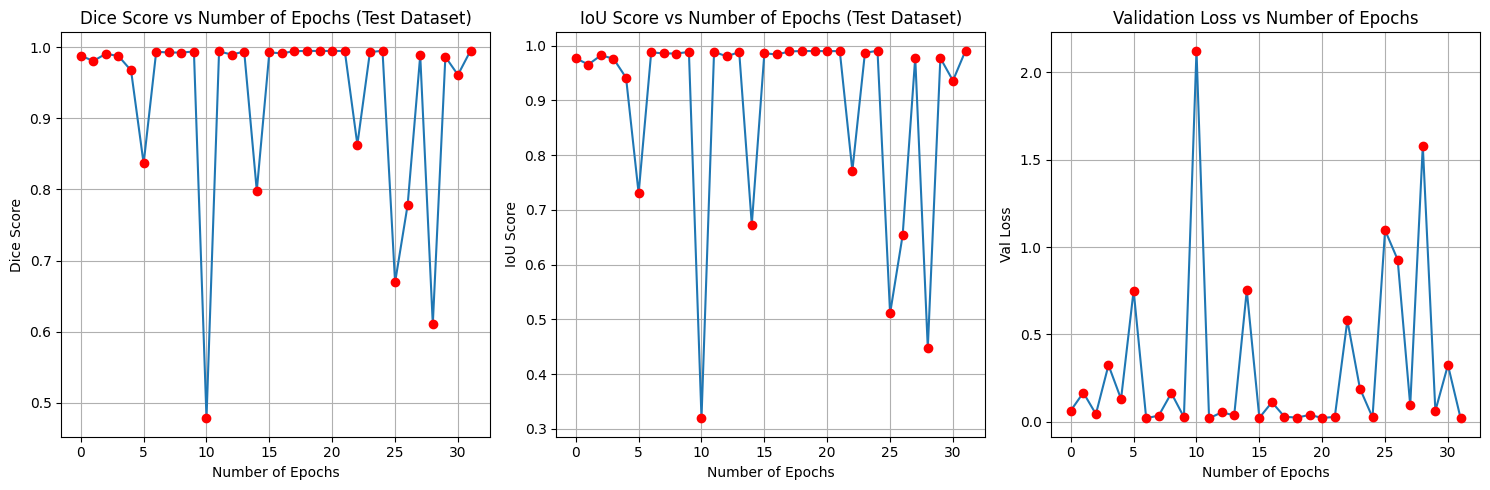

In [34]:
# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot for dice_score_track
axes[0].plot(dice_score_track)
axes[0].scatter(range(0, len(dice_score_track)), dice_score_track, color='r', zorder=3)
#axes[0].set_xticks(range(1, len(dice_score_track) + 1))
axes[0].set_xlabel("Number of Epochs")
axes[0].set_ylabel("Dice Score")
axes[0].set_title("Dice Score vs Number of Epochs (Test Dataset)")
axes[0].grid(True)

# Plot for iou_score_track
axes[1].plot(iou_score_track)
axes[1].scatter(range(0, len(iou_score_track)), iou_score_track, color='r', zorder=3)
#axes[1].set_xticks(range(1, len(iou_score_track) + 1))
axes[1].set_xlabel("Number of Epochs")
axes[1].set_ylabel("IoU Score")
axes[1].set_title("IoU Score vs Number of Epochs (Test Dataset)")
axes[1].grid(True)

# Plot for val_loss_track
axes[2].plot(val_loss_track)
axes[2].scatter(range(0, len(val_loss_track)), val_loss_track, color='r', zorder=3)
#axes[2].set_xticks(range(1, len(val_loss_track) + 1))
axes[2].set_xlabel("Number of Epochs")
axes[2].set_ylabel("Val Loss")
axes[2].set_title("Validation Loss vs Number of Epochs")
axes[2].grid(True)

# Display the plots
plt.tight_layout()
plt.show()

## Testing

In [19]:
old_weights = model.state_dict()
model.load_state_dict(early_stopping.best_weights)

<All keys matched successfully>

### Output model predictions to "model_outputs"

In [35]:
model.eval()
for idx, (x, y) in enumerate(test_dataset):
    x: torch.Tensor
    y: torch.Tensor

    x = x.to(device=device).unsqueeze(0)
    with torch.no_grad():
        preds = model(x)
        if deep_supervision:
            preds = preds[-1]
        preds = torch.sigmoid(preds)
        preds = (preds > 0.5).float()

    save_image(preds, f"{model_output_folder}\\{idx}_pred.png")
    save_image(y.unsqueeze(1), f"{model_output_folder}\\{idx}_real.png")
    
    if idx + 1 == 50:
        break

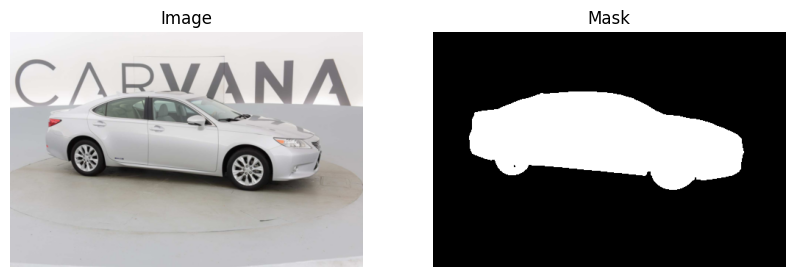

In [36]:
with torch.no_grad():
    mask = model(test_image.unsqueeze(0).to(device))

if deep_supervision:
    mask = mask[-1]

mask = torch.sigmoid(mask).squeeze(0).cpu().detach()
    
mask = (mask > 0.5).float()

# Convert tensors to NumPy format for plotting
image = test_image.permute(1, 2, 0).numpy()
mask = mask.permute(1, 2, 0).numpy()

# Plot side by side
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(image)
ax[0].set_title("Image")
ax[0].axis("off")

ax[1].imshow(mask, cmap='gray') # Use grayscale colormap for mask
ax[1].set_title("Mask")
ax[1].axis("off")

plt.show()

### Calculate Dice Score

In [37]:
num_correct = 0
num_pixels = 0
dice_score = 0.0
model.eval()

with torch.no_grad():
    for x, y in tqdm(test_loader, total=len(test_loader)):
        x, y = x.to(device), y.to(device)

        # Get model predictions
        preds = model(x)[-1] if deep_supervision else model(x)
        preds = torch.sigmoid(preds)
        preds = (preds > 0.5).float()

        # Compute pixel-wise accuracy
        num_correct += (preds == y).sum().item()
        num_pixels += y.numel()

        # Compute Dice score (batch-wise)
        dice_score += (2 * (preds * y).sum().item()) / (
            (preds + y).sum().item() + 1e-8
        )

# Print results
accuracy = num_correct / num_pixels * 100
average_dice = dice_score / len(test_loader)

print(f"Got {num_correct}/{num_pixels} with acc {accuracy:.2f}%")
print(f"Dice score: {average_dice:.4f}")


100%|██████████| 128/128 [00:32<00:00,  3.92it/s]

Got 77993486/78182400 with acc 99.76%
Dice score: 0.9943


### Calculate Intersection over Under (IoU) score

In [38]:
total_iou = 0

for x, y in tqdm(test_dataset, total=len(test_dataset)):
    iou_score = model.iou_score(x, y)
    total_iou += iou_score

print(f"IoU Score: {total_iou / len(test_dataset)}")

100%|██████████| 509/509 [00:31<00:00, 16.19it/s]

IoU Score: 0.9886428772349255


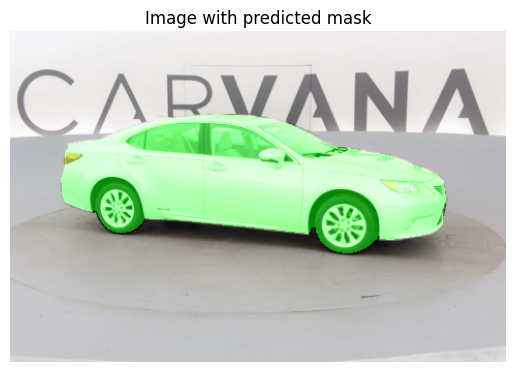

In [40]:
with torch.no_grad():
    preds = model(test_image.unsqueeze(0).to(device))

mask = torch.sigmoid(preds[-1] if deep_supervision else preds) 

if deep_supervision:
    mask = F.sigmoid(preds[-1]).squeeze(0).cpu().detach()
else:
    mask = F.sigmoid(preds).squeeze(0).cpu().detach()
    
mask = (mask > 0.5).float()

mask = mask.expand_as(test_image)
green_tinted = test_image.clone()
green_tinted[1] = torch.clamp(green_tinted[1] + 0.5, 0, 1)

result = test_image * (1 - mask) + green_tinted * mask

result = result.permute(1, 2, 0).numpy()

plt.imshow(result)
plt.title("Image with predicted mask")
plt.axis('off')
plt.show()

### Save model

In [39]:
if continue_training:
    num_models = len(os.listdir('models'))
    model_path = f"models\\model_{num_models}.pth"
    torch.save({
        'model_state_dict': old_weights,
        'model_best': early_stopping.best_weights,
        'optimizer_state_dict': optimizer.state_dict(),
        'iou_track': iou_score_track,
        'dice_track': dice_score_track,
        'val_track': val_loss_track,
        'deep_supervision': deep_supervision,
        'in_channels': IN_CHANNELS,
        'out_channels': OUT_CHANNELS,
        'L': L,
        'test_image': test_image,
        'test_mask': test_mask,
        'images': images
    }, model_path)